# Deep Learning 

# Deep Learning Fundamentals

## References & Resources

This week covers foundational deep learning concepts inspired by:
- **MIT 6.S191**: Introduction to Deep Learning
- **Stanford CS231n**: Convolutional Neural Networks for Visual Recognition  
- **Stanford CS224n**: Natural Language Processing with Deep Learning
- **Goodfellow et al.**: "Deep Learning" (MIT Press) - The canonical reference
- **Chollet**: "Deep Learning with Python" - Practical implementation guide

---

## Key Concepts

### 1. Universal Approximation Theorem
**Theorem**: A feedforward neural network with one hidden layer containing a finite number of neurons can approximate any continuous function on a compact domain.

**Implication**: MLPs are theoretically powerful enough for any problem, but practical depth helps:
- **Shallow networks**: Need exponentially many neurons
- **Deep networks**: Require fewer total parameters (exponential efficiency gain)

### 2. Gradient Descent & Backpropagation

**Chain Rule**: For y = f(g(x)), dy/dx = (dy/dg)(dg/dx)

**Backpropagation**: Efficient computation of gradients by applying chain rule backward through network layers.

```
Forward pass:  x → layer1 → layer2 → ... → output
Backward pass: ∇output ← ∇layer2 ← ∇layer1 ← x
```

### 3. Vanishing/Exploding Gradients

**Problem**: In deep networks, gradients propagate backward through many layers:
- **Vanishing**: Gradients become very small (σ'(z) ≤ 0.25), making early layers learn slowly
- **Exploding**: Gradients become very large, causing instability

**Solutions**:
- **Batch Normalization**: Normalize activations to mean=0, std=1
- **Residual Connections (ResNet)**: Skip connections let gradients flow directly
- **LSTM/GRU gates**: Explicitly control information flow
- **Gradient Clipping**: Clip large gradients to [-c, c]

### 4. Optimization Algorithms

**Stochastic Gradient Descent (SGD)**:
- θ := θ - lr · ∇L(θ)
- Simple but noisy and slow convergence

**Momentum**:
- v := β·v - lr·∇L(θ)
- θ := θ + v
- Accelerates convergence by accumulating velocity

**Adam (Adaptive Moment Estimation)**:
- Combines momentum + RMSprop (adaptive learning rates)
- Most popular modern optimizer
- Formula: θ := θ - lr · m̂_t / (√v̂_t + ε)

## Activation Functions

| Activation | Formula | Range | Pros | Cons |
|---|---|---|---|---|
| **Sigmoid** | σ(z) = 1/(1+e^-z) | (0,1) | Interpretable probability | Vanishing gradients |
| **ReLU** | f(z) = max(0,z) | [0,∞) | Fast, prevents saturation | Dead neurons, not differentiable at 0 |
| **Tanh** | tanh(z) = (e^z - e^-z)/(e^z + e^-z) | (-1,1) | Zero-centered | Vanishing gradients |
| **Leaky ReLU** | f(z) = max(αz, z), α≈0.01 | (-∞,∞) | Prevents dead neurons | Slightly slower |
| **ELU** | f(z) = z if z>0, α(e^z-1) if z≤0 | (-α,∞) | Smooth, mean≈0 | Slightly slower |

**Recommendation**: Start with ReLU for hidden layers, sigmoid for binary classification output.

---

## Regularization Techniques

### Overfitting Problem
A model that fits training data too well fails on test data because it memorizes noise rather than learning patterns.

```
Underfitting:    Bias ↑, Variance ↓  → Poor on train & test
Good fit:        Bias ~, Variance ~  → Good on both
Overfitting:     Bias ↓, Variance ↑  → Good on train, poor on test
```

### L1/L2 Regularization

**L2 Regularization** (Weight Decay):
- Loss = MSE + λ·Σ(w²)
- Penalizes large weights uniformly
- All weights shrink toward zero

**L1 Regularization** (Lasso):
- Loss = MSE + λ·Σ|w|
- Creates sparsity (exactly zero weights)
- Feature selection

### Dropout (Thinned Networks)
**Idea**: During training, randomly deactivate neurons with probability p.
- Forces network to learn redundant representations
- At test time, use all neurons but scale by (1-p)
- Equivalent to averaging exponentially-many thinned networks

**Effect**: Acts as ensemble of thinned networks → reduces overfitting

### Early Stopping
Monitor validation loss during training:
- If validation loss increases for N consecutive epochs → stop
- Prevents memorizing noise
- Simple but effective

### Batch Normalization
**Why it helps**:
1. Normalizes layer inputs to N(0,1) → stable gradients
2. Higher learning rates possible
3. Acts as regularizer (adds noise during training)
4. Reduces internal covariate shift

In [2]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv') #make sure to replace with your data directory
df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

In [3]:
X.shape

(299, 11)

In [4]:
y.value_counts(normalize=True)

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

## Train / Test Split

We split data **before** any feature selection. This is critical:

- Feature selection must only see training data — otherwise we leak test information
- `stratify=y` ensures both splits have the same class ratio (~68% survived, ~32% died)
- `random_state=42` makes results reproducible

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=42)

In [6]:
print('X train shape: ',X_train.shape)
print('y train shape: ',y_train.shape)
print('X test shape: ',X_test.shape)
print('y test shape: ',y_test.shape)
print('y train: ',y_train.value_counts(normalize=True))
print('y test: ',y_test.value_counts(normalize=True))

X train shape:  (209, 11)
y train shape:  (209,)
X test shape:  (90, 11)
y test shape:  (90,)
y train:  DEATH_EVENT
0    0.679426
1    0.320574
Name: proportion, dtype: float64
y test:  DEATH_EVENT
0    0.677778
1    0.322222
Name: proportion, dtype: float64


In [7]:
feature_names = X.columns
feature_names

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='object')

## Normalize Data

**Why normalize before Lasso/Elastic Net?**

Lasso and Elastic Net use coefficient magnitudes to decide which features to drop. If features are on different scales (e.g., `platelets` ≈ 200,000 vs `age` ≈ 60), large-scale features will dominate unfairly.

`StandardScaler` transforms each feature to **mean = 0, std = 1**, so all features compete on equal footing.

> **Rule:** Always fit the scaler on training data only (`fit_transform`), then apply to test data (`transform`). Fitting on test data would leak information.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Multi-layer Perceptron 

Epoch 50/500, Train Loss: 0.5491, Val Loss: 0.5532, Test Loss: 0.5991, Train Acc: 0.7117, Val Acc: 0.7366, Test Acc: 0.6889
Epoch 100/500, Train Loss: 0.5098, Val Loss: 0.5273, Test Loss: 0.6207, Train Acc: 0.7560, Val Acc: 0.7605, Test Acc: 0.6778
Epoch 150/500, Train Loss: 0.4835, Val Loss: 0.5163, Test Loss: 0.6204, Train Acc: 0.7835, Val Acc: 0.7275, Test Acc: 0.6667
Epoch 200/500, Train Loss: 0.4801, Val Loss: 0.4900, Test Loss: 0.6056, Train Acc: 0.7859, Val Acc: 0.7418, Test Acc: 0.6778
Epoch 250/500, Train Loss: 0.4570, Val Loss: 0.4472, Test Loss: 0.6078, Train Acc: 0.7811, Val Acc: 0.7892, Test Acc: 0.6889
Epoch 300/500, Train Loss: 0.4361, Val Loss: 0.4062, Test Loss: 0.6139, Train Acc: 0.7967, Val Acc: 0.8232, Test Acc: 0.6778
Epoch 350/500, Train Loss: 0.4302, Val Loss: 0.4207, Test Loss: 0.6528, Train Acc: 0.8122, Val Acc: 0.8278, Test Acc: 0.6667
Epoch 400/500, Train Loss: 0.4128, Val Loss: 0.3956, Test Loss: 0.7454, Train Acc: 0.8278, Val Acc: 0.8424, Test Acc: 0.7000
E

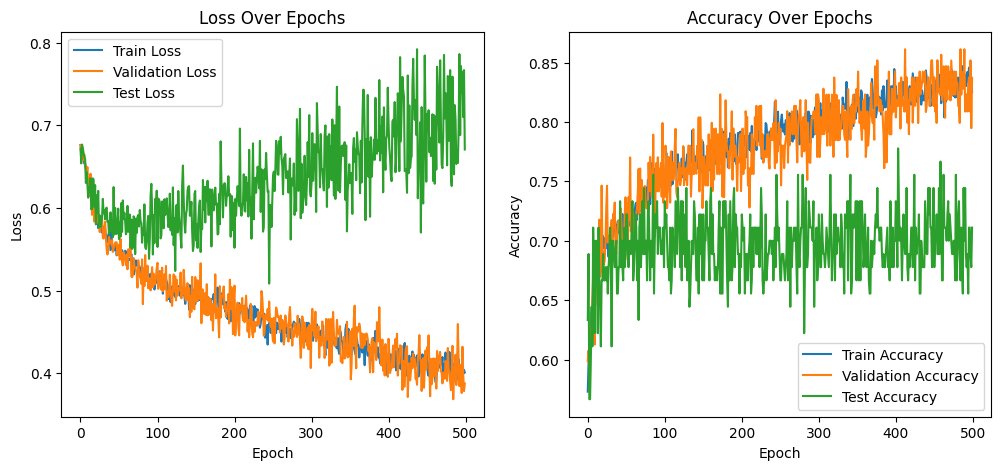

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

class MLPTrainer:
    def __init__(self, input_dim, hidden1=16, hidden2=8, dropout=0.3, lr=0.001, k_folds=5, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._build_model(input_dim, hidden1, hidden2, dropout).to(self.device)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.k_folds = k_folds

        # For tracking
        self.train_losses, self.val_losses, self.test_losses = [], [], []
        self.train_accs, self.val_accs, self.test_accs = [], [], []

    class MLP(nn.Module):
        def __init__(self, input_dim, hidden1=16, hidden2=8, dropout=0.3):
            super().__init__()
            # Hidden layers
            self.layer1 = nn.Linear(input_dim, hidden1)
            self.bn1 = nn.BatchNorm1d(hidden1)
            self.layer2 = nn.Linear(hidden1, hidden2)
            self.bn2 = nn.BatchNorm1d(hidden2)
            self.dropout = nn.Dropout(dropout)
            # Output layer
            self.output = nn.Linear(hidden2, 1)
            
        def forward(self, x):
            # Hidden layer 1
            x = self.layer1(x)
            x = self.bn1(x)
            x = torch.sigmoid(x)
            x = self.dropout(x)
            
            # Hidden layer 2
            x = self.layer2(x)
            x = self.bn2(x)
            x = torch.sigmoid(x)
            x = self.dropout(x)
            
            # Output layer (no dropout)
            x = self.output(x)
            x = torch.sigmoid(x)
            return x

    def _build_model(self, input_dim, hidden1, hidden2, dropout):
        return self.MLP(input_dim, hidden1, hidden2, dropout)

    @staticmethod
    def compute_accuracy(y_true, y_pred):
        y_pred_labels = (y_pred >= 0.5).float()
        correct = (y_pred_labels == y_true).float().sum()
        return (correct / y_true.shape[0]).item()

    def fit(self, X_train, y_train, X_test, y_test, epochs=500):
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1).to(self.device)

        for epoch in range(epochs):
            skf = StratifiedKFold(n_splits=self.k_folds, shuffle=True, random_state=42)
            fold_train_losses, fold_val_losses = [], []
            fold_train_accs, fold_val_accs = [], []

            for train_idx, val_idx in skf.split(X_train_tensor, y_train):
                X_fold_train = X_train_tensor[train_idx].to(self.device)
                y_fold_train = y_train_tensor[train_idx].to(self.device)
                X_fold_val = X_train_tensor[val_idx].to(self.device)
                y_fold_val = y_train_tensor[val_idx].to(self.device)

                # Forward pass
                self.optimizer.zero_grad()
                outputs = self.model(X_fold_train)
                loss = self.criterion(outputs, y_fold_train)
                loss.backward()
                self.optimizer.step()

                fold_train_losses.append(loss.item())
                fold_train_accs.append(self.compute_accuracy(y_fold_train, outputs))

                # Validation
                with torch.no_grad():
                    val_outputs = self.model(X_fold_val)
                    val_loss = self.criterion(val_outputs, y_fold_val)
                    fold_val_losses.append(val_loss.item())
                    fold_val_accs.append(self.compute_accuracy(y_fold_val, val_outputs))

            # Record averages
            self.train_losses.append(np.mean(fold_train_losses))
            self.val_losses.append(np.mean(fold_val_losses))
            self.train_accs.append(np.mean(fold_train_accs))
            self.val_accs.append(np.mean(fold_val_accs))

            # Test metrics
            with torch.no_grad():
                test_outputs = self.model(X_test_tensor)
                self.test_losses.append(self.criterion(test_outputs, y_test_tensor).item())
                self.test_accs.append(self.compute_accuracy(y_test_tensor, test_outputs))

            if (epoch+1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, "
                      f"Train Loss: {self.train_losses[-1]:.4f}, Val Loss: {self.val_losses[-1]:.4f}, Test Loss: {self.test_losses[-1]:.4f}, "
                      f"Train Acc: {self.train_accs[-1]:.4f}, Val Acc: {self.val_accs[-1]:.4f}, Test Acc: {self.test_accs[-1]:.4f}")

    def plot_metrics(self):
        # Loss plot
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.plot(self.test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss Over Epochs')
        plt.legend()

        # Accuracy plot
        plt.subplot(1,2,2)
        plt.plot(self.train_accs, label='Train Accuracy')
        plt.plot(self.val_accs, label='Validation Accuracy')
        plt.plot(self.test_accs, label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy Over Epochs')
        plt.legend()
        plt.show()


trainer = MLPTrainer(input_dim=X_train.shape[1])
trainer.fit(X_train, y_train, X_test, y_test, epochs=500)
trainer.plot_metrics()

In [ ]:
#A simpler MLP with 2 hidden layers 

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader


# Define the neural network class
class MultilayerPerceptron(nn.Module):
    def __init__(self, num_features, hidden_size1, hidden_size2, num_classes):
        super(MultilayerPerceptron, self).__init__()
        # 1st hidden layer
        self.linear_1 = nn.Linear(num_features, hidden_size1)
        # 2nd linear layer
        self.linear_2 = nn.Linear(hidden_size1, hidden_size2)
        # output layer
        self.linear_out = nn.Linear(hidden_size2, num_classes)
        
    def forward(self, x):
        x = F.relu(self.linear_1(x))
        x = F.relu(self.linear_2(x))
        logits = self.linear_out(x)
        probas = torch.sigmoid(logits)
        return logits, probas

# Generate random data
np.random.seed(0)
X = np.random.rand(1000, 2)  # Increased to 1000 samples to demonstrate batching
y = (X[:, 0] + X[:, 1] > 1).astype(int)
# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Create dataset and dataloader
# Create dataset and dataloader using TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define hyperparameters
num_features = 2
hidden_size1 = 64
hidden_size2 = 32
num_classes = 1
learning_rate = 0.01
epochs = 100

# Create the model
model = MultilayerPerceptron(num_features, hidden_size1, hidden_size2, num_classes)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop with batches
for epoch in range(epochs):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch_X, batch_y in dataloader:
        # Forward pass
        logits, outputs = model(batch_X)
        
        # Compute loss
        loss = criterion(outputs, batch_y)
        total_loss += loss.item()
        num_batches += 1
        
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate average loss for the epoch
    avg_loss = total_loss / num_batches
    print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')

# Testing the trained model
model.eval()
with torch.no_grad():
    test_data = torch.tensor([[0.7, 0.6]], dtype=torch.float32)
    _, prediction = model(test_data)
    predicted_class = (prediction > 0.5).item()
    
print(f"Prediction for [0.7, 0.6]: {predicted_class} (0 represents Pass, 1 represents Fail)")

# Convolutional Neural Networks (CNNs)

## What is a CNN?

**Convolutional Neural Networks** are designed to exploit **spatial structure** in data by:
1. **Local connectivity**: Neurons only connect to small regions (receptive fields)
2. **Weight sharing**: Same filters apply across the entire input
3. **Hierarchical feature learning**: Lower layers learn edges/textures, higher layers learn complex patterns

### CNN Architecture Components

**Convolutional Layer:**
- Applies filters across input to detect patterns
- Filter weights are learned during training
- Multiple filters detect different features

**Pooling Layer:**
- Downsamples spatial dimensions (e.g., max pooling, average pooling)
- Reduces computation and emphasizes strongest activations
- Makes the network translation-invariant

**Fully Connected Layer:**
- Standard neural network layer at the end
- Combines learned features for final prediction

### Why CNNs for Heart Failure?

While heart failure data is **not naturally 2D spatial**, we can reshape it as a **1D sequence** where:
- Each feature becomes a "channel"
- Time-ordered medical measurements form a sequence
- Local patterns (e.g., combinations of ejection fraction + creatinine) matter

---

## 1D CNN Implementation

# CNN Deep Dive: From LeCun to ResNets

## Historical Context
- **1998 LeNet-5** (LeCun et al.): First successful CNN for MNIST (handwriting)
- **2012 AlexNet** (Krizhevsky et al.): Deep CNN that won ImageNet competition
- **2014 VGGNet** (Simonyan & Zisserman): Showed depth matters (16-19 layers)
- **2015 ResNet** (He et al.): Skip connections enabled 152-layer networks

## How Convolutions Work

**Standard Layer**: Each neuron connects to ALL previous activations
- Fully connected 1000×1000 matrix = 1,000,000 parameters

**Convolutional Layer**: Each neuron connects to small LOCAL region (receptive field)
- 3×3 filter × 64 filters = 576 parameters
- **Shared weights**: Same filter applied across entire input
- **Locality**: Only nearby pixels matter for local features

### Receptive Field
The area in input that affects one output neuron.

```
Input:      [1][2][3][4][5]
Filter:        [a][b][c]
Output:           [y1]  (receptive field = positions 1,2,3)
```

Stacking layers increases receptive field:
- Layer 1: 3×3 filter → receptive field = 3×3
- Layer 2: 3×3 filter on Layer 1 → receptive field = 5×5 (in input space)
- Layer 3: receptive field = 7×7

### Parameter Efficiency Example
Detecting a 7×7 pattern:
- **Fully connected**: 49 parameters per output neuron
- **3 CNN layers**: 3×(3×3 filters) = 27 parameters (exponential savings!)

---

## CNN Architectures for Different Tasks

| Architecture | Year | Key Innovation | Use Case |
|---|---|---|---|
| **LeNet** | 1998 | Conv + pooling + FC | Small images (MNIST) |
| **AlexNet** | 2012 | Deep conv + ReLU + dropout | ImageNet (large images) |
| **VGG** | 2014 | Stacking 3×3 layers | Transfer learning benchmark |
| **GoogleNet** | 2014 | Inception modules (multi-scale) | Efficiency, speed |
| **ResNet** | 2015 | Skip connections | Very deep (152+ layers) |
| **DenseNet** | 2016 | Dense connections | Feature reuse |
| **EfficientNet** | 2019 | Compound scaling | Mobile/edge devices |

**Key Takeaway**: Modern CNNs use skip connections because gradient flow matters more than depth alone.

In [ ]:
class CNN1DTrainer:
    def __init__(self, input_dim, num_filters=32, kernel_size=3, dropout=0.3, lr=0.001, k_folds=5, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._build_model(input_dim, num_filters, kernel_size, dropout).to(self.device)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.k_folds = k_folds

        self.train_losses, self.val_losses, self.test_losses = [], [], []
        self.train_accs, self.val_accs, self.test_accs = [], [], []

    class CNN1D(nn.Module):
        def __init__(self, input_dim, num_filters=32, kernel_size=3, dropout=0.3):
            super().__init__()
            # Conv1d: (batch, channels=1, length=input_dim)
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, padding=1)
            self.bn1 = nn.BatchNorm1d(num_filters)
            self.pool1 = nn.MaxPool1d(kernel_size=2)
            
            self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters*2, kernel_size=kernel_size, padding=1)
            self.bn2 = nn.BatchNorm1d(num_filters*2)
            self.pool2 = nn.MaxPool1d(kernel_size=2)
            
            self.dropout = nn.Dropout(dropout)
            
            # Calculate flattened size after convolutions
            # input_dim -> pool1 (/ 2) -> pool2 (/ 2)
            flattened_size = (input_dim // 4) * (num_filters * 2)
            
            self.fc1 = nn.Linear(flattened_size, 64)
            self.fc2 = nn.Linear(64, 1)
            
        def forward(self, x):
            # x shape: (batch, input_dim) -> reshape to (batch, 1, input_dim)
            x = x.unsqueeze(1)
            
            # Conv block 1
            x = self.conv1(x)
            x = self.bn1(x)
            x = torch.relu(x)
            x = self.pool1(x)
            x = self.dropout(x)
            
            # Conv block 2
            x = self.conv2(x)
            x = self.bn2(x)
            x = torch.relu(x)
            x = self.pool2(x)
            x = self.dropout(x)
            
            # Flatten and FC layers
            x = x.flatten(1)
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.dropout(x)
            x = self.fc2(x)
            x = torch.sigmoid(x)
            return x

    def _build_model(self, input_dim, num_filters, kernel_size, dropout):
        return self.CNN1D(input_dim, num_filters, kernel_size, dropout)

    @staticmethod
    def compute_accuracy(y_true, y_pred):
        y_pred_labels = (y_pred >= 0.5).float()
        correct = (y_pred_labels == y_true).float().sum()
        return (correct / y_true.shape[0]).item()

    def fit(self, X_train, y_train, X_test, y_test, epochs=500):
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1).to(self.device)

        for epoch in range(epochs):
            skf = StratifiedKFold(n_splits=self.k_folds, shuffle=True, random_state=42)
            fold_train_losses, fold_val_losses = [], []
            fold_train_accs, fold_val_accs = [], []

            for train_idx, val_idx in skf.split(X_train_tensor, y_train):
                X_fold_train = X_train_tensor[train_idx].to(self.device)
                y_fold_train = y_train_tensor[train_idx].to(self.device)
                X_fold_val = X_train_tensor[val_idx].to(self.device)
                y_fold_val = y_train_tensor[val_idx].to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(X_fold_train)
                loss = self.criterion(outputs, y_fold_train)
                loss.backward()
                self.optimizer.step()

                fold_train_losses.append(loss.item())
                fold_train_accs.append(self.compute_accuracy(y_fold_train, outputs))

                with torch.no_grad():
                    val_outputs = self.model(X_fold_val)
                    val_loss = self.criterion(val_outputs, y_fold_val)
                    fold_val_losses.append(val_loss.item())
                    fold_val_accs.append(self.compute_accuracy(y_fold_val, val_outputs))

            self.train_losses.append(np.mean(fold_train_losses))
            self.val_losses.append(np.mean(fold_val_losses))
            self.train_accs.append(np.mean(fold_train_accs))
            self.val_accs.append(np.mean(fold_val_accs))

            with torch.no_grad():
                test_outputs = self.model(X_test_tensor)
                self.test_losses.append(self.criterion(test_outputs, y_test_tensor).item())
                self.test_accs.append(self.compute_accuracy(y_test_tensor, test_outputs))

            if (epoch+1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, "
                      f"Train Loss: {self.train_losses[-1]:.4f}, Val Loss: {self.val_losses[-1]:.4f}, Test Loss: {self.test_losses[-1]:.4f}, "
                      f"Train Acc: {self.train_accs[-1]:.4f}, Val Acc: {self.val_accs[-1]:.4f}, Test Acc: {self.test_accs[-1]:.4f}")

    def plot_metrics(self):
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.plot(self.test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('1D CNN - Loss Over Epochs')
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(self.train_accs, label='Train Accuracy')
        plt.plot(self.val_accs, label='Validation Accuracy')
        plt.plot(self.test_accs, label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('1D CNN - Accuracy Over Epochs')
        plt.legend()
        plt.show()


# Train 1D CNN
cnn_trainer = CNN1DTrainer(input_dim=X_train.shape[1], num_filters=32, kernel_size=3)
cnn_trainer.fit(X_train, y_train, X_test, y_test, epochs=500)
cnn_trainer.plot_metrics()

# Recurrent Neural Networks (RNNs)

## What is an RNN?

**Recurrent Neural Networks** are designed to process **sequential data** with **temporal dependencies**:
1. **Hidden state**: Maintains information from previous timesteps
2. **Sequential processing**: Processes input one timestep at a time
3. **Backpropagation through time (BPTT)**: Gradients flow backward through the sequence

### RNN Variants

**Vanilla RNN:**
- Simplest form but suffers from vanishing gradients on long sequences
- Formula: h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)

**LSTM (Long Short-Term Memory):**
- Solves vanishing gradient problem with gating mechanisms
- **Input gate**: Controls what new info enters the cell
- **Forget gate**: Controls what info is discarded
- **Output gate**: Controls what info is output

**GRU (Gated Recurrent Unit):**
- Simpler than LSTM with only 2 gates (reset + update)
- Similar performance with fewer parameters

### Why RNNs for Heart Failure?

Heart failure data can be viewed as a **time series**:
- Sequential patient records over time
- Earlier measurements influence predictions
- RNNs naturally capture temporal patterns

---

## LSTM Implementation

# RNN Deep Dive: From Vanilla RNNs to Transformers

## The Sequence Modeling Problem

**Challenge**: Process variable-length sequences where order matters.
- Text: "The cat sat on the mat" (sequential order critical)
- Time series: Stock prices over time (past prices predict future)
- Speech: Audio frames depend on previous frames
- DNA: Sequences of nucleotides

**Why not just use MLPs?**
- MLPs have fixed input size
- No way to handle variable-length sequences
- No notion of "time" or sequence order

---

## RNN Core Mechanism

### Vanilla RNN (Simplest Form)

**Equations**:
```
h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)
y_t = W_hy * h_t + b_y
```

Where:
- h_t = hidden state at time t (memory)
- x_t = input at time t
- W_ih, W_hh, W_hy = weight matrices (shared across time)

**Advantage**: Single weight matrix applied to all timesteps (parameter sharing)

**Problem**: **Vanishing/Exploding Gradients Through Time**

When backpropagating through T timesteps:
```
dh_t/dh_{t-1} = W_hh^T · tanh'(...)
```

For deep sequences (large T), this product becomes:
- Very small: dL/dh_0 ≈ 0 (vanishing gradients)
- Very large: dL/dh_0 → ∞ (exploding gradients)

### LSTM: Solution via Gating

**Key Idea**: Use multiplicative gates to control information flow

```
Forget gate:  f_t = σ(W_f·[h_{t-1}, x_t] + b_f)  ∈ [0,1]
Input gate:   i_t = σ(W_i·[h_{t-1}, x_t] + b_i)  ∈ [0,1]
Candidate:    C̃_t = tanh(W_c·[h_{t-1}, x_t] + b_c)
Cell state:   C_t = f_t ⊙ C_{t-1} + i_t ⊙ C̃_t
Output gate:  o_t = σ(W_o·[h_{t-1}, x_t] + b_o)  ∈ [0,1]
Hidden state: h_t = o_t ⊙ tanh(C_t)
```

**Why this works**:
- **Cell state C_t** has path with only addition (no squashing)
- Gradients flow through **f_t** gate: if f_t ≈ 1, gradient ≈ 1 (no vanishing)
- If f_t ≈ 0, older information is forgotten (selective retention)

### GRU: Simpler Alternative

Combines forget and input gates into single "update gate":

```
Reset gate:  r_t = σ(W_r·[h_{t-1}, x_t] + b_r)
Update gate: z_t = σ(W_z·[h_{t-1}, x_t] + b_z)
Candidate:   h̃_t = tanh(W·[r_t ⊙ h_{t-1}, x_t] + b)
Hidden:      h_t = (1-z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t
```

- **Fewer parameters than LSTM** (2 gates vs 3)
- **Similar performance** in most tasks
- Preferred when data is limited

---

## RNN Applications & Variants

| Task | Architecture | Notes |
|---|---|---|
| **Classification** | Many-to-one (use final h_T) | Sentiment, health risk prediction |
| **Sequence labeling** | Many-to-many (output per step) | Named entity recognition, POS tagging |
| **Seq2Seq** | Many-to-many (encoder-decoder) | Machine translation, question answering |
| **Language modeling** | Many-to-many (predict next token) | Text generation, next word prediction |

### Attention Mechanism (2014)

**Problem**: Encoder-decoder for long sequences loses early information.

**Solution**: Allow decoder to "attend to" relevant input positions.

```
Attention(Q, K, V) = softmax(Q·K^T / √d_k) · V
```

- Q = Query (decoder state): "What do I need?"
- K = Key (encoder states): "What can I offer?"
- V = Value (encoder states): "Here's the actual info"
- softmax gives weights α ∈ [0,1] summing to 1

### Transformer (2017): Self-Attention Without RNNs

**Key Innovation**: Attention can work without recurrence!
- Each position attends to all other positions in parallel
- No sequential dependency → massive parallelization
- Led to BERT, GPT, and modern language models

**Attention mechanism advantages**:
1. Solves long-range dependency problem (better than RNNs)
2. Parallel computation (faster training)
3. Interpretable: attention weights show which inputs matter

---

## Practical Best Practices for Deep Learning

Based on Andrej Karpathy's "A Recipe for Training Neural Networks" and Google's ML best practices.

### 1. Start Simple, Add Complexity Gradually

```
Baseline MLP (2 layers)
    ↓ If underfitting
    ↓ Add hidden layer / more neurons
    ↓ Add regularization if overfitting
    ↓ Increase learning rate / epochs
    ↓ Add domain-specific architectures (CNN/RNN)
```

### 2. Data-First Approach

**Before building a fancy model:**
1. Understand your data
   - Visualize feature distributions
   - Check for outliers, missing values
   - Ensure correct train/val/test splits

2. Check if supervised learning is feasible
   - Can humans solve this task?
   - Is there signal in the data?
   - Test simple baseline (logistic regression)

3. Only then: try deep learning

### 3. Hyperparameter Selection Strategy

**Learning Rate** (most important):
- Too small: convergence is slow
- Too large: loss oscillates or diverges
- Start with lr=0.001, adjust based on loss curves

**Batch Size**:
- Small (16-32): noisy gradients, acts as regularizer
- Large (256+): cleaner gradients, might get stuck in sharp minima
- Sweet spot: 32-128 for most problems

**Number of Layers & Units**:
- Start with 1-2 hidden layers
- Double hidden layer size before doubling depth
- For N features, try 2-4× features in hidden layer

**Dropout**:
- Standard: p=0.5 for fully connected, p=0.3 for CNNs
- Reduce if underfitting, increase if overfitting

### 4. Training Checklist

- [ ] Normalize inputs (StandardScaler or MinMaxScaler)
- [ ] Use stratified splits (for imbalanced datasets)
- [ ] Plot loss/accuracy curves (detect overfitting early)
- [ ] Use validation set to tune hyperparameters
- [ ] Save best model (checkpoint on best validation loss)
- [ ] Evaluate only on test set (once at the end)

### 5. Debugging Common Issues

| Problem | Likely Cause | Solution |
|---|---|---|
| Loss is NaN | Learning rate too high, exploding gradients | Decrease LR, add gradient clipping |
| Loss not decreasing | Learning rate too low, bad initialization | Increase LR, check data normalization |
| Train loss ↓ but val loss ↑ | Overfitting | Add dropout, L2 regularization, early stopping |
| Loss oscillates wildly | Batch size too small, LR too high | Increase batch size, decrease LR |
| Validation accuracy plateaus | Underfitting | Add layers, increase capacity, train longer |

### 6. Model Selection Strategy

**For this heart failure dataset:**

| Model | Best For | Complexity |
|---|---|---|
| **Logistic Regression** | Baseline | Low |
| **Random Forest** | Non-linear patterns | Medium |
| **MLP (2-3 layers)** | Moderate non-linearity | Medium |
| **CNN** | Local feature interactions | High |
| **LSTM** | Temporal patterns (if data is sequential) | Very High |

**Recommendation**: Start with Logistic Regression → RF → MLP. Only use CNN/LSTM if MLP underperforms and you have a good reason to believe the data has structure CNNs/LSTMs can exploit.

In [ ]:
class LSTMTrainer:
    def __init__(self, input_dim, hidden_size=32, num_layers=2, dropout=0.3, lr=0.001, k_folds=5, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._build_model(input_dim, hidden_size, num_layers, dropout).to(self.device)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.k_folds = k_folds

        self.train_losses, self.val_losses, self.test_losses = [], [], []
        self.train_accs, self.val_accs, self.test_accs = [], [], []

    class LSTMNet(nn.Module):
        def __init__(self, input_dim, hidden_size=32, num_layers=2, dropout=0.3):
            super().__init__()
            # LSTM: (batch, seq_len, input_dim) -> (batch, seq_len, hidden_size)
            self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_size, 
                               num_layers=num_layers, dropout=dropout, batch_first=True)
            self.fc1 = nn.Linear(hidden_size, 64)
            self.fc2 = nn.Linear(64, 1)
            self.dropout = nn.Dropout(dropout)
            
        def forward(self, x):
            # x shape: (batch, input_dim)
            # Reshape to (batch, seq_len=1, input_dim) for LSTM
            x = x.unsqueeze(1)
            
            # LSTM forward pass
            lstm_out, (h_n, c_n) = self.lstm(x)
            # Use final hidden state: h_n[-1] is (batch, hidden_size)
            x = h_n[-1]
            
            # FC layers
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.dropout(x)
            x = self.fc2(x)
            x = torch.sigmoid(x)
            return x

    def _build_model(self, input_dim, hidden_size, num_layers, dropout):
        return self.LSTMNet(input_dim, hidden_size, num_layers, dropout)

    @staticmethod
    def compute_accuracy(y_true, y_pred):
        y_pred_labels = (y_pred >= 0.5).float()
        correct = (y_pred_labels == y_true).float().sum()
        return (correct / y_true.shape[0]).item()

    def fit(self, X_train, y_train, X_test, y_test, epochs=500):
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1).to(self.device)

        for epoch in range(epochs):
            skf = StratifiedKFold(n_splits=self.k_folds, shuffle=True, random_state=42)
            fold_train_losses, fold_val_losses = [], []
            fold_train_accs, fold_val_accs = [], []

            for train_idx, val_idx in skf.split(X_train_tensor, y_train):
                X_fold_train = X_train_tensor[train_idx].to(self.device)
                y_fold_train = y_train_tensor[train_idx].to(self.device)
                X_fold_val = X_train_tensor[val_idx].to(self.device)
                y_fold_val = y_train_tensor[val_idx].to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(X_fold_train)
                loss = self.criterion(outputs, y_fold_train)
                loss.backward()
                self.optimizer.step()

                fold_train_losses.append(loss.item())
                fold_train_accs.append(self.compute_accuracy(y_fold_train, outputs))

                with torch.no_grad():
                    val_outputs = self.model(X_fold_val)
                    val_loss = self.criterion(val_outputs, y_fold_val)
                    fold_val_losses.append(val_loss.item())
                    fold_val_accs.append(self.compute_accuracy(y_fold_val, val_outputs))

            self.train_losses.append(np.mean(fold_train_losses))
            self.val_losses.append(np.mean(fold_val_losses))
            self.train_accs.append(np.mean(fold_train_accs))
            self.val_accs.append(np.mean(fold_val_accs))

            with torch.no_grad():
                test_outputs = self.model(X_test_tensor)
                self.test_losses.append(self.criterion(test_outputs, y_test_tensor).item())
                self.test_accs.append(self.compute_accuracy(y_test_tensor, test_outputs))

            if (epoch+1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, "
                      f"Train Loss: {self.train_losses[-1]:.4f}, Val Loss: {self.val_losses[-1]:.4f}, Test Loss: {self.test_losses[-1]:.4f}, "
                      f"Train Acc: {self.train_accs[-1]:.4f}, Val Acc: {self.val_accs[-1]:.4f}, Test Acc: {self.test_accs[-1]:.4f}")

    def plot_metrics(self):
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.plot(self.test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('LSTM - Loss Over Epochs')
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(self.train_accs, label='Train Accuracy')
        plt.plot(self.val_accs, label='Validation Accuracy')
        plt.plot(self.test_accs, label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('LSTM - Accuracy Over Epochs')
        plt.legend()
        plt.show()


# Train LSTM
lstm_trainer = LSTMTrainer(input_dim=X_train.shape[1], hidden_size=32, num_layers=2)
lstm_trainer.fit(X_train, y_train, X_test, y_test, epochs=500)
lstm_trainer.plot_metrics()

# Model Comparison

## Summary: MLP vs CNN vs LSTM

In [ ]:
# Compare test accuracies
models = ['MLP', 'CNN 1D', 'LSTM']
final_accuracies = [
    trainer.test_accs[-1],
    cnn_trainer.test_accs[-1],
    lstm_trainer.test_accs[-1]
]

plt.figure(figsize=(8, 5))
plt.bar(models, final_accuracies, color=['blue', 'green', 'red'])
plt.ylabel('Test Accuracy')
plt.title('Final Test Accuracy: MLP vs CNN 1D vs LSTM')
plt.ylim([0, 1])
for i, acc in enumerate(final_accuracies):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center')
plt.show()

print("Final Test Accuracies:")
for model, acc in zip(models, final_accuracies):
    print(f"  {model}: {acc:.4f}")

# Detailed comparison table
comparison_df = pd.DataFrame({
    'Model': models,
    'Final Test Accuracy': final_accuracies,
    'Parameters': [
        'Simple, fully connected',
        'Local patterns (convolutions)',
        'Temporal dependencies (LSTM)'
    ],
    'Best For': [
        'Tabular, no structure',
        'Spatial/sequential structure',
        'Time series, long-term deps'
    ]
})

print("\n", comparison_df.to_string(index=False))